In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from src.audio_mixer import mixer
import pandas as pd 

## Spectograms

In [92]:
audio_file_path = './data/demo/audio/common_voice_pl_20642745.mp3'
y, sr = librosa.load(audio_file_path)

In [104]:
audio_file_path = './data/demo/audio/common_voice_pl_20608830.mp3'
y, sr = librosa.load(audio_file_path)


In [105]:
S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)

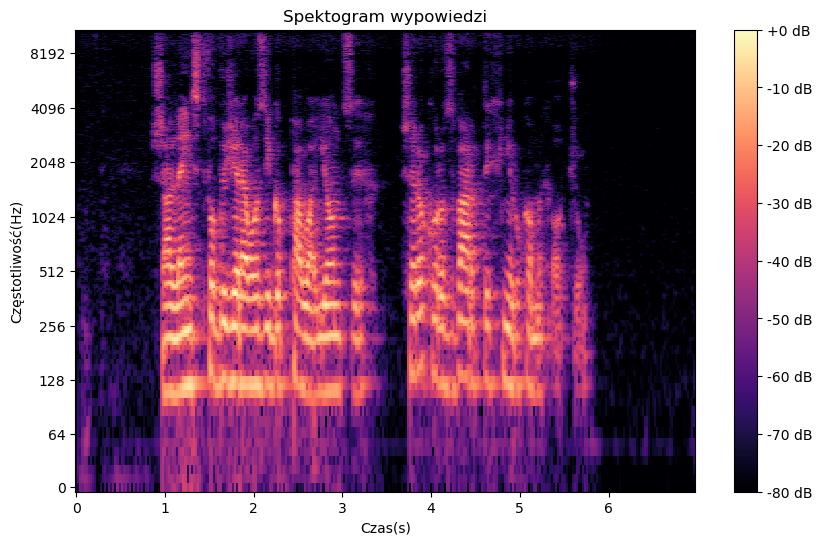

In [106]:
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram wypowiedzi')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


In [95]:
noise_file_path = './data/demo/noise/30823-8-0-0.wav'

y, sr = librosa.load(noise_file_path)

S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)


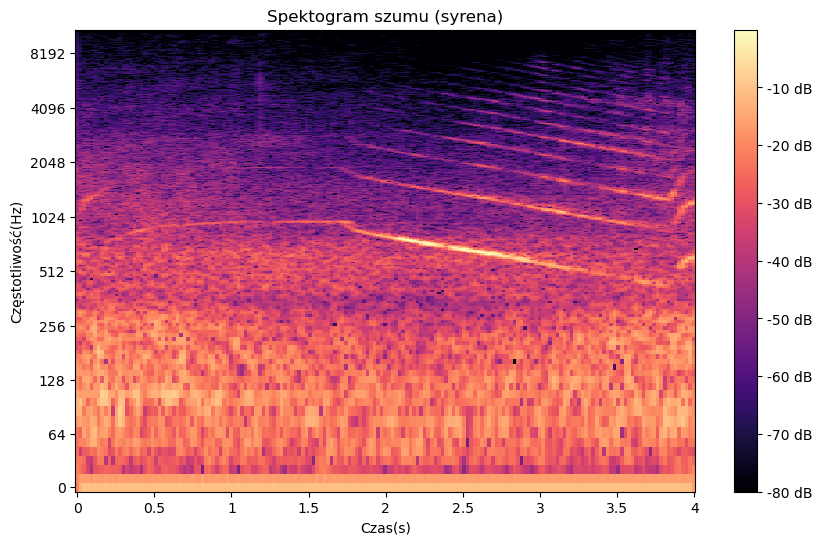

In [96]:
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram szumu (syrena)')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


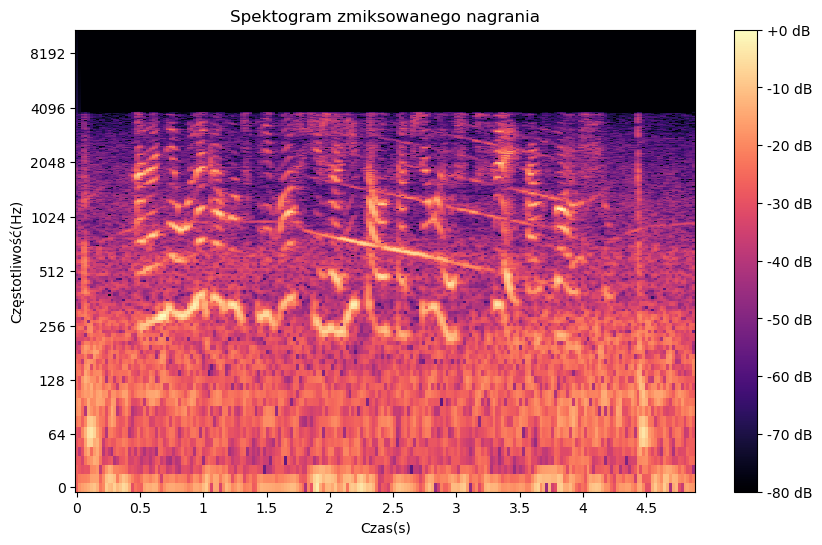

In [108]:
noise_file_path = './data/temporary/common_voice_pl_21642620.wav'


y, sr = librosa.load(noise_file_path)

S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram zmiksowanego nagrania')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


## Audiofile

In [98]:
def plot_waveforms(audio_file_paths, colors, legend_labels):
    plt.figure(figsize=(10, 6))

    for i, audio_file_path in enumerate(audio_file_paths):
        # Load the audio file
        y, sr = librosa.load(audio_file_path)
        
        # Time axis
        time = np.linspace(0, len(y) / sr, len(y))
        
        # Plot the waveform with the specified color and legend label
        plt.plot(time, y, color=colors[i], label=legend_labels[i],markersize=0.1,linewidth=1, alpha=1)
    
    # Adding labels and title
    plt.xlabel('Czas (s)')
    plt.ylabel('Amplituda')
    plt.title('Przebieg sygnału')
    
    # Adding grid
    plt.grid(True)
    
    # Display legend with custom labels
    plt.legend(loc='upper right')
    
    # Display the plot
    plt.show()
    

In [9]:
mixer('./data/demo/audio/common_voice_pl_21642620.mp3','./data/demo/noise/30823-8-0-0.wav', 10, './data/temporary/common_voice_pl_21642620.wav')

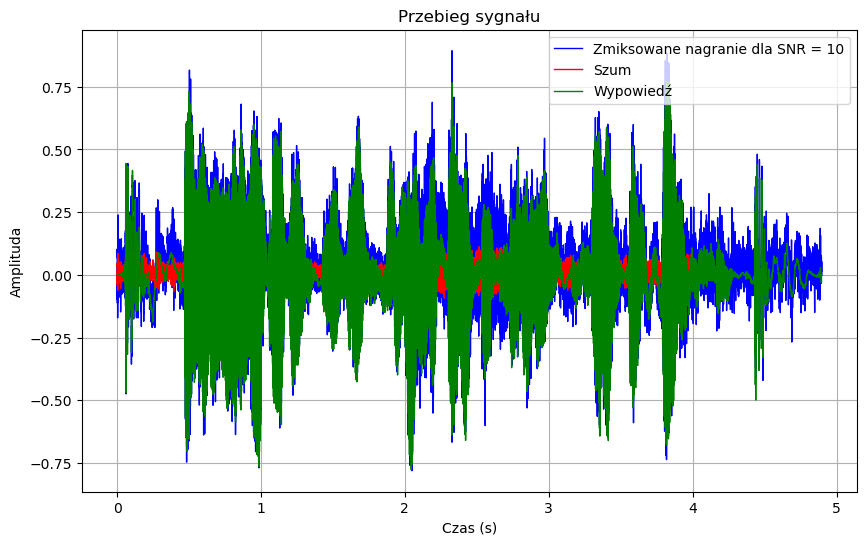

In [99]:
audio_file_paths = ['./data/temporary/common_voice_pl_21642620.wav', './data/demo/noise/30823-8-0-0.wav', './data/demo/audio/common_voice_pl_21642620.mp3']
# Colors for each waveform
colors = ['blue', 'red', 'green']

legend_labels = ['Zmiksowane nagranie dla SNR = 10','Szum', 'Wypowiedź']

# Plot the waveforms
plot_waveforms(audio_file_paths, colors,legend_labels)

In [5]:
batch_df = pd.read_csv('./images_to_batch/wykres_1.csv')

In [6]:
batch_df

,Wall time,Step,Value
0,1.711498e+09,25,1.5060
1,1.711498e+09,50,1.4442
2,1.711498e+09,75,1.1312
3,1.711499e+09,100,0.8122
4,1.711499e+09,125,0.6313
...,...,...,...
155,1.711570e+09,3900,0.0001
156,1.711571e+09,3925,0.0001
157,1.711571e+09,3950,0.0001
158,1.711572e+09,3975,0.0001


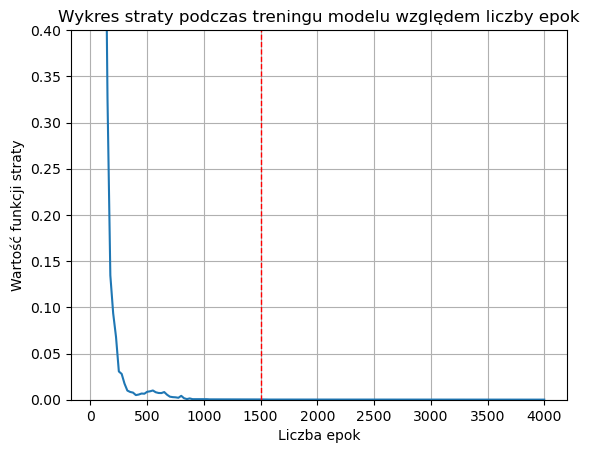

In [35]:
plt.plot(batch_df['Step'],batch_df['Value'])
plt.xlabel("Liczba epok")
plt.ylabel('Wartość funkcji straty')
plt.title("Wykres straty podczas treningu modelu względem liczby epok")
plt.axvline(1500, color='red', linestyle='--', linewidth=1)
plt.ylim(0, 0.4)
plt.grid()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(1550, 0.09200000000000001, 'Przyjęta granica nauki modelu')

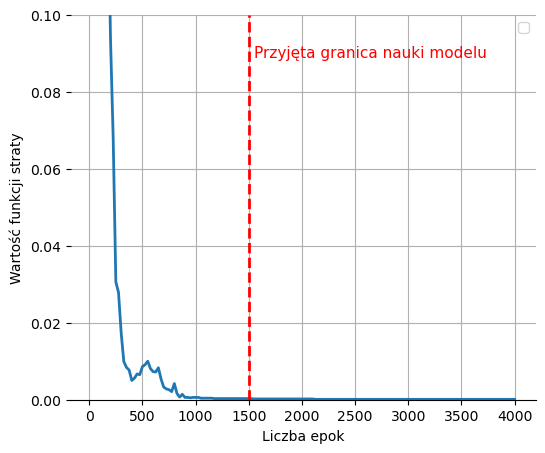

In [74]:
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the baseline
ax.plot(
    label="Baseline",
    color="lightgray",
    linestyle="--",
    linewidth=1,
)


ax.plot(batch_df['Step'],batch_df['Value'], linewidth=2)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
# --------------------END CHANGES------------------------

ax.set_xlabel("Liczba epok")
ax.set_ylabel('Wartość funkcji straty')

ax.axvline(1500, color='red', linestyle='--', linewidth=2)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid()
ax.text(1550, ax.get_ylim()[1] * 0.92, 'Przyjęta granica nauki modelu', color='red', ha='left', va='top', rotation=0, fontsize=11)

In [59]:
batch_time_df = pd.read_csv('./images_to_batch/wykres_2.csv')
batch_time_df

,Wall time,Step,Value
0,1.711498e+09,25,1.5060
1,1.711498e+09,50,1.4442
2,1.711498e+09,75,1.1312
3,1.711499e+09,100,0.8122
4,1.711499e+09,125,0.6313
...,...,...,...
155,1.711570e+09,3900,0.0001
156,1.711571e+09,3925,0.0001
157,1.711571e+09,3950,0.0001
158,1.711572e+09,3975,0.0001


In [60]:
batch_time_df['Wall_times_sec'] = batch_time_df['Wall time'] - batch_time_df['Wall time'][0]

In [62]:
batch_time_df['Wall_times_min'] = batch_time_df['Wall_times_sec'] / 60
batch_time_df['Wall_times_hour'] = batch_time_df['Wall_times_min'] / 60

In [63]:
batch_time_df['Wall_times_hour']

0       0.000000
1       0.134913
2       0.264631
3       0.394448
4       0.524155
         ...    
155    20.250065
156    20.378621
157    20.507445
158    20.636026
159    20.764731
Name: Wall_times_hour, Length: 160, dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(8.097, 0.09200000000000001, 'Czas treningu do granicy 8 godz 5 min')

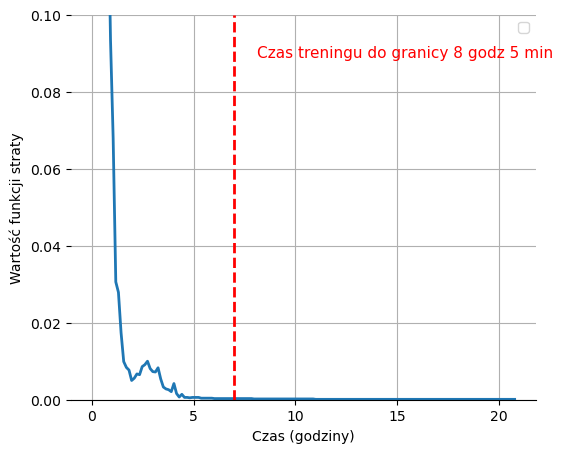

In [73]:

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the baseline
ax.plot(
    label="Baseline",
    color="lightgray",
    linestyle="--",
    linewidth=1,
)


ax.plot(batch_time_df['Wall_times_hour'],batch_df['Value'], linewidth=2)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
# --------------------END CHANGES------------------------

ax.set_xlabel("Czas (godziny)")
ax.set_ylabel('Wartość funkcji straty')
ax.axvline(7, color='red', linestyle='--', linewidth=2)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid()
ax.text(8.097, ax.get_ylim()[1] * 0.92, 'Czas treningu do granicy 8 godz 5 min', color='red', ha='left', va='top', rotation=0, fontsize=11)